In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version = 1, as_frame = False)

X = mnist.data
y = mnist.target.astype(np.int64)

In [3]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [5]:
y

array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))

In [6]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("Pixel range:", X.min(), "to", X.max())
print("First 10 labels: ", y[:10])

X Shape: (70000, 784)
y Shape: (70000,)
Pixel range: 0 to 255
First 10 labels:  [5 0 4 1 9 2 1 3 1 4]


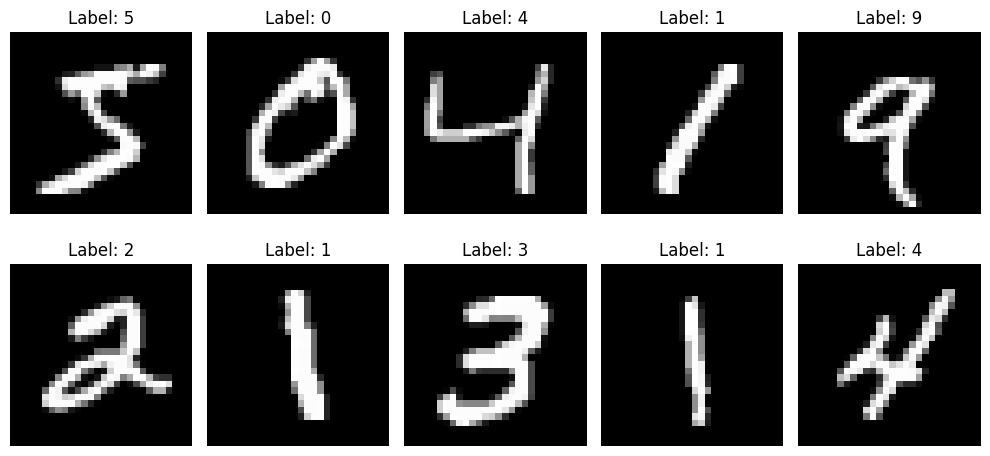

In [10]:
fig, axes = plt.subplots(2, 5, figsize = (10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap = "gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Normalizing pixel values 
X = X / 255.0

# MNIST images are already flattened by fetch_optimal
# (70_000, 784)
# If they were 28x28 images, we would use :
# X = X.reshape(-1, 784)

print("X shape:", X.shape)
print("Pixel range:", X.min(), "to", X.max())

# One-hot encode labels
Y = np.zeros((y.size, 10))
Y[np.arange(y.size), y] = 1

print("Y shape:", Y.shape)
print("First label:", y[0])
print("One-hot representation:", Y[0])

# Split into train / validation / test
# MNIST's standard split: first 60,000 for training, last 10,000 for testing
X_train_full = X[:60000]
Y_train_full = Y[:60000]

X_test = X[60000:]
Y_test = Y[60000:]

# Take 5,000 examples from the training set for validation
X_train = X_train_full[:55000]
Y_train = Y_train_full[:55000]

X_val = X_train_full[55000:]
Y_val = Y_train_full[55000:]

print("\nTrain:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

X shape: (70000, 784)
Pixel range: 0.0 to 1.5378700499807765e-05
Y shape: (70000, 10)
First label: 5
One-hot representation: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Train: (55000, 784) (55000, 10)
Validation: (5000, 784) (5000, 10)
Test: (10000, 784) (10000, 10)


In [15]:
# Architecture 
input_size = 784
hidden1_size = 256
hidden2_size = 128
output_size = 10

#He Initialization
W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1_size))

W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
b2 = np.zeros((1, hidden2_size))

W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(2 / hidden2_size)
b3 = np.zeros((1, output_size))

#Check shapes 
print("W1:", W1.shape, "b1:", b1.shape)
print("W2:", W2.shape, "b2:", b2.shape)
print("W3:", W3.shape, "b3:", b3.shape)

W1: (784, 256) b1: (1, 256)
W2: (256, 128) b2: (1, 128)
W3: (128, 10) b3: (1, 10)


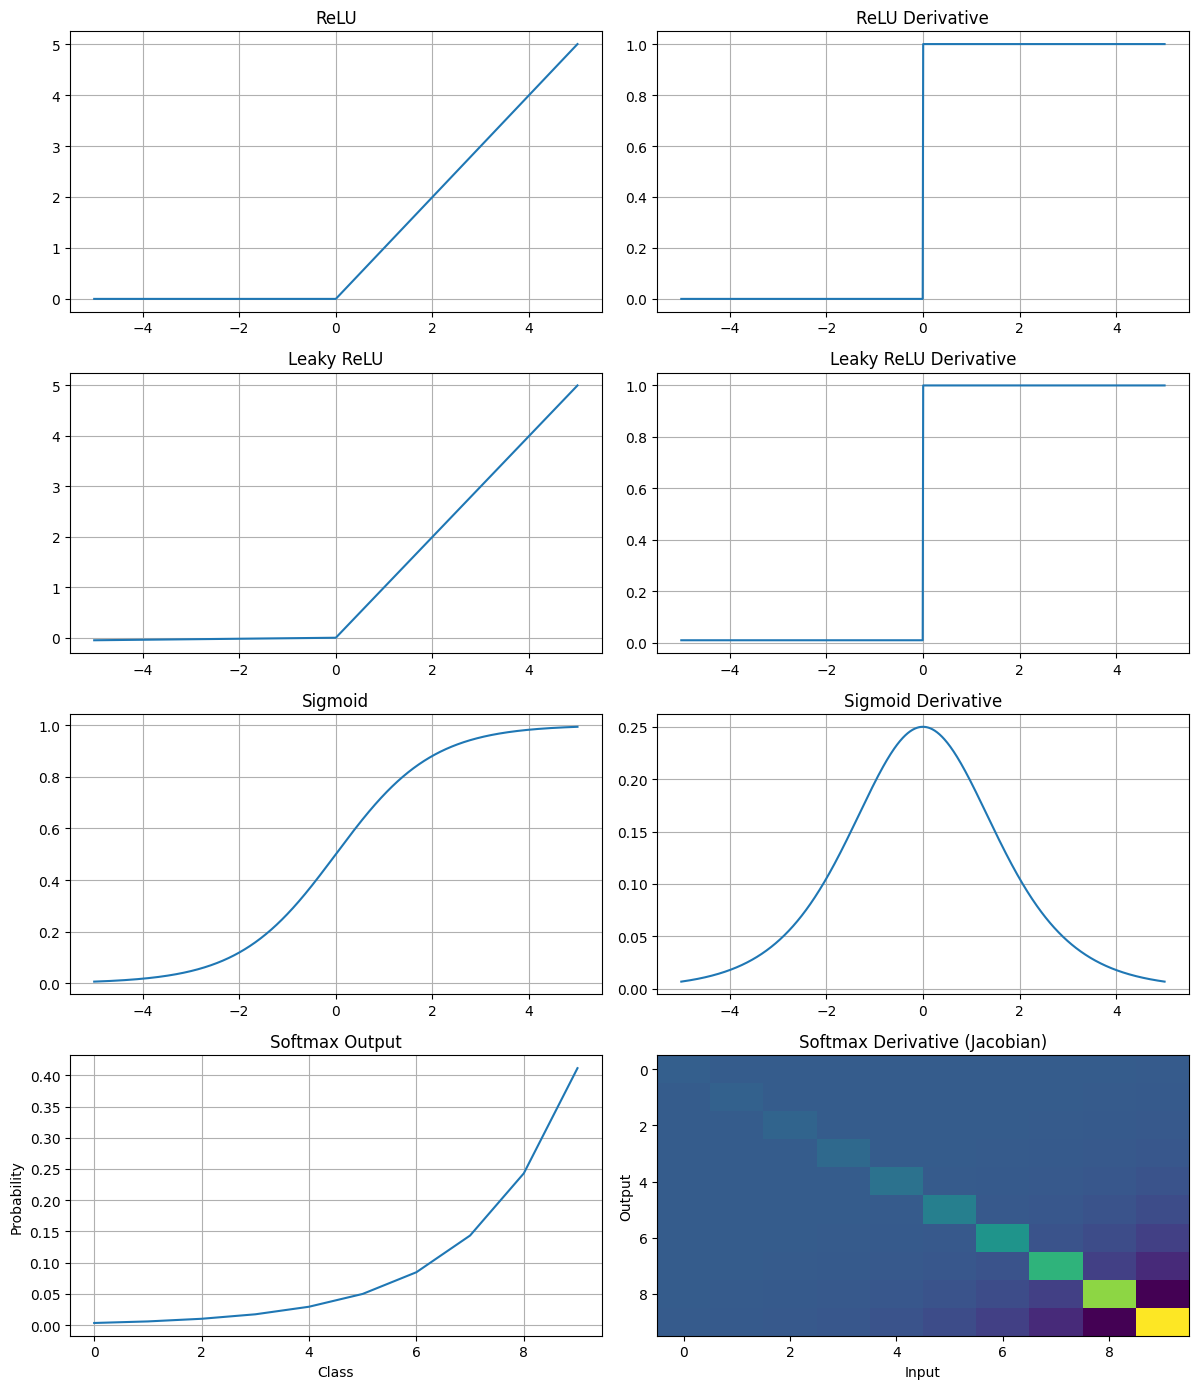

In [16]:
# -------------------------
# Activation functions
# -------------------------

def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)


def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)


def sigmoid(z):
    # Clip for numerical stability
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


def softmax(z):
    # Subtract max for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def softmax_derivative(z):
    """
    Jacobian of softmax for one sample.

    Note:
    In our final network, softmax + cross-entropy
    simplifies during backpropagation, so we won't
    explicitly need this full Jacobian.
    """
    s = softmax(z)

    # For a single sample
    return np.diag(s[0]) - np.outer(s[0], s[0])


# -------------------------
# Plot functions + derivatives
# -------------------------

z = np.linspace(-5, 5, 1000)

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

# ReLU
axes[0, 0].plot(z, relu(z))
axes[0, 0].set_title("ReLU")
axes[0, 0].grid(True)

axes[0, 1].plot(z, relu_derivative(z))
axes[0, 1].set_title("ReLU Derivative")
axes[0, 1].grid(True)

# Leaky ReLU
axes[1, 0].plot(z, leaky_relu(z))
axes[1, 0].set_title("Leaky ReLU")
axes[1, 0].grid(True)

axes[1, 1].plot(z, leaky_relu_derivative(z))
axes[1, 1].set_title("Leaky ReLU Derivative")
axes[1, 1].grid(True)

# Sigmoid
axes[2, 0].plot(z, sigmoid(z))
axes[2, 0].set_title("Sigmoid")
axes[2, 0].grid(True)

axes[2, 1].plot(z, sigmoid_derivative(z))
axes[2, 1].set_title("Sigmoid Derivative")
axes[2, 1].grid(True)

# Softmax
# Softmax is normally applied to a vector rather than
# plotted as a simple scalar function.
sample_z = np.linspace(-5, 5, 20).reshape(2, 10)
sample_probs = softmax(sample_z)

axes[3, 0].plot(sample_probs[0])
axes[3, 0].set_title("Softmax Output")
axes[3, 0].set_xlabel("Class")
axes[3, 0].set_ylabel("Probability")
axes[3, 0].grid(True)

# Show one row of the softmax Jacobian
jacobian = softmax_derivative(sample_z)
axes[3, 1].imshow(jacobian, aspect="auto")
axes[3, 1].set_title("Softmax Derivative (Jacobian)")
axes[3, 1].set_xlabel("Input")
axes[3, 1].set_ylabel("Output")

plt.tight_layout()
plt.show()

In [17]:
def forward_propagation(X):
    # Layer 1: 784 → 256
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Layer 2: 256 → 128
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Layer 3: 128 → 10
    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    # Cache values for backpropagation
    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "A3": A3
    }

    return A3, cache


# Test the forward pass on a small batch
X_batch = X_train[:5]

predictions, cache = forward_propagation(X_batch)

print("Output shape:", predictions.shape)
print("Predictions:\n", predictions)
print("Probability sums:", predictions.sum(axis=1))

Output shape: (5, 10)
Predictions:
 [[0.10000037 0.1000007  0.09999989 0.09999836 0.10000101 0.09999908
  0.10000002 0.10000134 0.09999979 0.09999944]
 [0.09999995 0.10000006 0.10000058 0.09999913 0.10000022 0.09999918
  0.10000056 0.10000053 0.10000004 0.09999974]
 [0.10000039 0.10000001 0.10000039 0.09999887 0.10000055 0.09999926
  0.09999963 0.10000081 0.09999977 0.10000031]
 [0.10000064 0.10000005 0.10000018 0.09999913 0.10000042 0.09999988
  0.10000006 0.10000021 0.09999961 0.09999983]
 [0.10000038 0.10000014 0.09999988 0.09999978 0.10000052 0.09999946
  0.10000005 0.1000006  0.09999951 0.0999997 ]]
Probability sums: [1. 1. 1. 1. 1.]


In [18]:
def cross_entropy_loss(Y_true, Y_pred):
    """
    Categorical cross-entropy loss.

    Y_true: one-hot encoded labels, shape (m, 10)
    Y_pred: softmax predictions, shape (m, 10)
    """
    epsilon = 1e-15

    # Prevent log(0)
    Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)

    # Cross-entropy for each sample
    loss = -np.sum(Y_true * np.log(Y_pred), axis=1)

    # Average over the batch
    return np.mean(loss)


def accuracy(Y_true, Y_pred):
    """
    Classification accuracy.

    Y_true: one-hot encoded labels
    Y_pred: softmax predictions
    """
    true_labels = np.argmax(Y_true, axis=1)
    predicted_labels = np.argmax(Y_pred, axis=1)

    return np.mean(true_labels == predicted_labels)


# Test the functions
loss = cross_entropy_loss(Y_test[:5], predictions)
acc = accuracy(Y_test[:5], predictions)

print("Loss:", loss)
print("Accuracy:", acc)

Loss: 2.302578919510635
Accuracy: 0.6


In [19]:
def backward_propagation(X, Y, cache):
    # Retrieve cached forward-pass values
    Z1 = cache["Z1"]
    A1 = cache["A1"]

    Z2 = cache["Z2"]
    A2 = cache["A2"]

    Z3 = cache["Z3"]
    A3 = cache["A3"]

    m = X.shape[0]  # Number of samples in the batch

    # ============================================================
    # OUTPUT LAYER
    # ============================================================

    # Softmax + Cross-Entropy simplifies to:
    # dZ3 = A3 - Y
    dZ3 = A3 - Y

    # Z3 = A2 @ W3 + b3
    #
    # dW3 = (A2.T @ dZ3) / m
    # db3 = sum(dZ3, axis=0) / m
    dW3 = (A2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # ============================================================
    # HIDDEN LAYER 2
    # ============================================================

    # Gradient flowing backward through W3:
    # dA2 = dZ3 @ W3.T
    dA2 = dZ3 @ W3.T

    # A2 = ReLU(Z2)
    #
    # dZ2 = dA2 * ReLU'(Z2)
    dZ2 = dA2 * relu_derivative(Z2)

    # Z2 = A1 @ W2 + b2
    #
    # dW2 = (A1.T @ dZ2) / m
    # db2 = sum(dZ2, axis=0) / m
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # ============================================================
    # HIDDEN LAYER 1
    # ============================================================

    # Gradient flowing backward through W2:
    # dA1 = dZ2 @ W2.T
    dA1 = dZ2 @ W2.T

    # A1 = ReLU(Z1)
    #
    # dZ1 = dA1 * ReLU'(Z1)
    dZ1 = dA1 * relu_derivative(Z1)

    # Z1 = X @ W1 + b1
    #
    # dW1 = (X.T @ dZ1) / m
    # db1 = sum(dZ1, axis=0) / m
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Store all gradients
    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
        "dW3": dW3,
        "db3": db3
    }

    return gradients


# Test backpropagation
gradients = backward_propagation(
    X_batch,
    Y_train[:5],
    cache
)

for name, gradient in gradients.items():
    print(f"{name}: {gradient.shape}")

dW1: (784, 256)
db1: (1, 256)
dW2: (256, 128)
db2: (1, 128)
dW3: (128, 10)
db3: (1, 10)


In [20]:
class BatchNorm:
    def __init__(self, num_features, momentum=0.9, epsilon=1e-5):
        self.num_features = num_features
        self.momentum = momentum
        self.epsilon = epsilon

        # Learnable parameters
        # gamma = scale
        # beta  = shift
        self.gamma = np.ones((1, num_features))
        self.beta = np.zeros((1, num_features))

        # Running statistics used during inference
        self.running_mean = np.zeros((1, num_features))
        self.running_var = np.ones((1, num_features))

        # Cache used during backpropagation
        self.cache = None

    def forward(self, X, training=True):

        if training:
            # ----------------------------------------------------
            # 1. Calculate batch mean and variance
            # ----------------------------------------------------

            mean = np.mean(X, axis=0, keepdims=True)
            var = np.var(X, axis=0, keepdims=True)

            # ----------------------------------------------------
            # 2. Normalize
            #
            # X_hat = (X - mean) / sqrt(var + epsilon)
            # ----------------------------------------------------

            X_centered = X - mean
            std_inv = 1.0 / np.sqrt(var + self.epsilon)
            X_hat = X_centered * std_inv

            # ----------------------------------------------------
            # 3. Scale and shift
            #
            # Y = gamma * X_hat + beta
            # ----------------------------------------------------

            out = self.gamma * X_hat + self.beta

            # Update running statistics
            self.running_mean = (
                self.momentum * self.running_mean
                + (1 - self.momentum) * mean
            )

            self.running_var = (
                self.momentum * self.running_var
                + (1 - self.momentum) * var
            )

            # Save values needed during backpropagation
            self.cache = (
                X_hat,
                X_centered,
                std_inv,
                mean,
                var
            )

            return out

        else:
            # ----------------------------------------------------
            # INFERENCE
            # Use running statistics instead of current batch
            # ----------------------------------------------------

            X_hat = (
                X - self.running_mean
            ) / np.sqrt(self.running_var + self.epsilon)

            out = self.gamma * X_hat + self.beta

            return out

    def backward(self, dY):
        """
        Backward pass for BatchNorm.

        dY = gradient coming from the next layer.
        """

        X_hat, X_centered, std_inv, mean, var = self.cache

        m = dY.shape[0]

        # --------------------------------------------------------
        # Gradients for learnable parameters
        #
        # dgamma = sum(dY * X_hat)
        # dbeta  = sum(dY)
        # --------------------------------------------------------

        dgamma = np.sum(dY * X_hat, axis=0, keepdims=True)
        dbeta = np.sum(dY, axis=0, keepdims=True)

        # --------------------------------------------------------
        # Gradient with respect to input X
        #
        # Compact BatchNorm derivative:
        #
        # dX = (gamma / m) * std_inv *
        #      [m*dY - sum(dY)
        #       - X_hat*sum(dY*X_hat)]
        # --------------------------------------------------------

        dX = (
            self.gamma
            * std_inv
            / m
            * (
                m * dY
                - np.sum(dY, axis=0, keepdims=True)
                - X_hat * np.sum(dY * X_hat, axis=0, keepdims=True)
            )
        )

        return dX, dgamma, dbeta


# Create BatchNorm layers for our two hidden layers
bn1 = BatchNorm(hidden1_size)
bn2 = BatchNorm(hidden2_size)

print("BN1 gamma:", bn1.gamma.shape)
print("BN1 beta: ", bn1.beta.shape)

print("BN2 gamma:", bn2.gamma.shape)
print("BN2 beta: ", bn2.beta.shape)

BN1 gamma: (1, 256)
BN1 beta:  (1, 256)
BN2 gamma: (1, 128)
BN2 beta:  (1, 128)


In [21]:
class Dropout:
    def __init__(self, keep_prob=0.8):
        """
        keep_prob:
            Probability of keeping a neuron.

        Example:
            keep_prob = 0.8
            → keep 80%
            → drop 20%
        """
        self.keep_prob = keep_prob
        self.mask = None

    def forward(self, X, training=True):
        """
        Forward pass.

        During training:
            Randomly drop neurons and scale survivors.

        During inference:
            Do nothing.
        """

        if not training:
            return X

        # Create a random mask:
        # 1 = keep neuron
        # 0 = drop neuron
        self.mask = (
            np.random.rand(*X.shape) < self.keep_prob
        )

        # Inverted dropout:
        # Scale surviving activations by 1 / keep_prob
        return (X * self.mask) / self.keep_prob

    def backward(self, dY):
        """
        Backward pass.

        Dropped neurons contributed nothing during
        forward propagation, so their gradients are zero.
        """
        return (dY * self.mask) / self.keep_prob


# Create dropout layers for our hidden layers
dropout1 = Dropout(keep_prob=0.8)
dropout2 = Dropout(keep_prob=0.8)

print("Keep probability:", dropout1.keep_prob)
print("Drop probability:", 1 - dropout1.keep_prob)

Keep probability: 0.8
Drop probability: 0.19999999999999996


In [22]:
class SGD:
    """
    Plain / vanilla gradient descent.

    θ_new = θ - learning_rate * gradient
    """

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update(self, params, grads):
        for name in params:
            params[name] -= self.learning_rate * grads[name]

        return params


class MiniBatchSGD:
    """
    Mini-batch SGD.

    The gradient is calculated using a mini-batch,
    then parameters are updated.
    """

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate

    def update(self, params, grads):
        for name in params:
            params[name] -= self.learning_rate * grads[name]

        return params


class Adam:
    """
    Adam optimizer.

    Maintains:
        m = first moment (momentum)
        v = second moment (squared-gradient estimate)

    Uses bias correction before updating parameters.
    """

    def __init__(
        self,
        learning_rate=0.001,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8
    ):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        # First moment
        self.m = {}

        # Second moment
        self.v = {}

        # Time step
        self.t = 0

    def update(self, params, grads):
        self.t += 1

        for name in params:

            # Initialize moment vectors
            if name not in self.m:
                self.m[name] = np.zeros_like(params[name])
                self.v[name] = np.zeros_like(params[name])

            # ----------------------------------------------------
            # 1. Update first moment
            #
            # m_t = beta1*m_(t-1) + (1-beta1)*g_t
            # ----------------------------------------------------
            self.m[name] = (
                self.beta1 * self.m[name]
                + (1 - self.beta1) * grads[name]
            )

            # ----------------------------------------------------
            # 2. Update second moment
            #
            # v_t = beta2*v_(t-1)
            #       + (1-beta2)*g_t^2
            # ----------------------------------------------------
            self.v[name] = (
                self.beta2 * self.v[name]
                + (1 - self.beta2) * (grads[name] ** 2)
            )

            # ----------------------------------------------------
            # 3. Bias correction
            #
            # m_hat = m_t / (1-beta1^t)
            # v_hat = v_t / (1-beta2^t)
            # ----------------------------------------------------
            m_hat = self.m[name] / (1 - self.beta1 ** self.t)
            v_hat = self.v[name] / (1 - self.beta2 ** self.t)

            # ----------------------------------------------------
            # 4. Adam parameter update
            #
            # θ = θ - α * m_hat / (sqrt(v_hat) + epsilon)
            # ----------------------------------------------------
            params[name] -= (
                self.learning_rate
                * m_hat
                / (np.sqrt(v_hat) + self.epsilon)
            )

        return params


print("SGD, MiniBatchSGD, and Adam implemented.")

SGD, MiniBatchSGD, and Adam implemented.


In [23]:
def regularization_loss(
    W1, W2, W3,
    l2_lambda=0.0,
    l1_lambda=0.0
):
    """
    Calculate L1 and L2 regularization penalties.

    L2:
        lambda * sum(W^2) / (2m)

    L1:
        lambda * sum(|W|) / m

    Biases are not regularized.
    """

    l2_loss = (
        l2_lambda / 2
        * (
            np.sum(W1 ** 2)
            + np.sum(W2 ** 2)
            + np.sum(W3 ** 2)
        )
    )

    l1_loss = (
        l1_lambda
        * (
            np.sum(np.abs(W1))
            + np.sum(np.abs(W2))
            + np.sum(np.abs(W3))
        )
    )

    return l2_loss + l1_loss


def total_loss(
    Y_true,
    Y_pred,
    W1, W2, W3,
    l2_lambda=0.0,
    l1_lambda=0.0
):
    """
    Data loss + regularization penalty.
    """

    data_loss = cross_entropy_loss(Y_true, Y_pred)

    reg_loss = regularization_loss(
        W1, W2, W3,
        l2_lambda,
        l1_lambda
    )

    return data_loss + reg_loss


def add_regularization_to_gradients(
    gradients,
    W1, W2, W3,
    l2_lambda=0.0,
    l1_lambda=0.0,
    m=1
):
    """
    Add regularization gradients to dW.

    L2:
        d/dW [lambda/2 * W^2] = lambda * W

    L1:
        d/dW [lambda * |W|] = lambda * sign(W)
    """

    # L2 gradient:
    # dW_reg = lambda * W
    gradients["dW1"] += l2_lambda * W1
    gradients["dW2"] += l2_lambda * W2
    gradients["dW3"] += l2_lambda * W3

    # Optional L1 gradient:
    # dW_reg = lambda * sign(W)
    if l1_lambda > 0:
        gradients["dW1"] += l1_lambda * np.sign(W1)
        gradients["dW2"] += l1_lambda * np.sign(W2)
        gradients["dW3"] += l1_lambda * np.sign(W3)

    return gradients


# Example regularization strengths
l2_lambda = 1e-4
l1_lambda = 0.0

print("L2 lambda:", l2_lambda)
print("L1 lambda:", l1_lambda)

L2 lambda: 0.0001
L1 lambda: 0.0


In [31]:
# ============================================================
# FULL FORWARD PROPAGATION
# ============================================================

def forward_propagation_full(X, training=True):

    # --------------------------------------------------------
    # Layer 1: 784 → 256
    # --------------------------------------------------------
    Z1 = X @ W1 + b1

    # Batch Normalization
    BN1 = bn1.forward(Z1, training=training)

    # ReLU
    A1 = relu(BN1)

    # Dropout
    D1 = dropout1.forward(A1, training=training)

    # --------------------------------------------------------
    # Layer 2: 256 → 128
    # --------------------------------------------------------
    Z2 = D1 @ W2 + b2

    # Batch Normalization
    BN2 = bn2.forward(Z2, training=training)

    # ReLU
    A2 = relu(BN2)

    # Dropout
    D2 = dropout2.forward(A2, training=training)

    # --------------------------------------------------------
    # Output Layer: 128 → 10
    # --------------------------------------------------------
    Z3 = D2 @ W3 + b3

    # Softmax
    A3 = softmax(Z3)

    # Cache everything needed for backpropagation
    cache = {
        "Z1": Z1,
        "BN1": BN1,
        "A1": A1,
        "D1": D1,

        "Z2": Z2,
        "BN2": BN2,
        "A2": A2,
        "D2": D2,

        "Z3": Z3,
        "A3": A3
    }

    return A3, cache


# ============================================================
# FULL BACKWARD PROPAGATION
# ============================================================

def backward_propagation_full(X, Y, cache):

    Z1 = cache["Z1"]
    BN1 = cache["BN1"]
    A1 = cache["A1"]
    D1 = cache["D1"]

    Z2 = cache["Z2"]
    BN2 = cache["BN2"]
    A2 = cache["A2"]
    D2 = cache["D2"]

    Z3 = cache["Z3"]
    A3 = cache["A3"]

    m = X.shape[0]

    # ========================================================
    # OUTPUT LAYER
    # ========================================================

    # Softmax + Cross-Entropy
    dZ3 = A3 - Y

    # Z3 = D2 @ W3 + b3
    dW3 = (D2.T @ dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Gradient flowing into D2
    dD2 = dZ3 @ W3.T

    # ========================================================
    # DROPOUT 2
    # ========================================================

    dA2 = dropout2.backward(dD2)

    # ========================================================
    # RELU 2
    # ========================================================

    dBN2 = dA2 * relu_derivative(BN2)

    # ========================================================
    # BATCH NORMALIZATION 2
    # ========================================================

    dZ2, dgamma2, dbeta2 = bn2.backward(dBN2)

    # Z2 = D1 @ W2 + b2
    dW2 = (D1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Gradient flowing into D1
    dD1 = dZ2 @ W2.T

    # ========================================================
    # DROPOUT 1
    # ========================================================

    dA1 = dropout1.backward(dD1)

    # ========================================================
    # RELU 1
    # ========================================================

    dBN1 = dA1 * relu_derivative(BN1)

    # ========================================================
    # BATCH NORMALIZATION 1
    # ========================================================

    dZ1, dgamma1, dbeta1 = bn1.backward(dBN1)

    # Z1 = X @ W1 + b1
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # ========================================================
    # STORE ALL GRADIENTS
    # ========================================================

    gradients = {
        "W1": dW1,
        "b1": db1,

        "W2": dW2,
        "b2": db2,

        "W3": dW3,
        "b3": db3,

        "gamma1": dgamma1,
        "beta1": dbeta1,

        "gamma2": dgamma2,
        "beta2": dbeta2
    }

    return gradients


# ============================================================
# PARAMETERS
# ============================================================

params = {
    "W1": W1,
    "b1": b1,

    "W2": W2,
    "b2": b2,

    "W3": W3,
    "b3": b3,

    # BatchNorm parameters
    "gamma1": bn1.gamma,
    "beta1": bn1.beta,

    "gamma2": bn2.gamma,
    "beta2": bn2.beta
}


# ============================================================
# TRAINING SETTINGS
# ============================================================

epochs = 20
batch_size = 128

learning_rate = 0.001

l2_lambda = 1e-4
l1_lambda = 0.0


# ============================================================
# ADAM
# ============================================================

optimizer = Adam(
    learning_rate=learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
)


# ============================================================
# TRAINING LOOP
# ============================================================

n_samples = X_train.shape[0]

for epoch in range(epochs):

    # --------------------------------------------------------
    # Shuffle training data
    # --------------------------------------------------------

    permutation = np.random.permutation(n_samples)

    X_train_shuffled = X_train[permutation]
    Y_train_shuffled = Y_train[permutation]

    # --------------------------------------------------------
    # Mini-batch training
    # --------------------------------------------------------

    for start in range(0, n_samples, batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # ----------------------------------------------------
        # 1. FORWARD PASS
        # ----------------------------------------------------

        Y_pred, cache = forward_propagation_full(
            X_batch,
            training=True
        )

        # ----------------------------------------------------
        # 2. BACKWARD PASS
        # ----------------------------------------------------

        gradients = backward_propagation_full(
            X_batch,
            Y_batch,
            cache
        )

        # ----------------------------------------------------
        # 3. ADD REGULARIZATION GRADIENTS
        # ----------------------------------------------------

        gradients["W1"] += l2_lambda * W1
        gradients["W2"] += l2_lambda * W2
        gradients["W3"] += l2_lambda * W3

        if l1_lambda > 0:

            gradients["W1"] += l1_lambda * np.sign(W1)
            gradients["W2"] += l1_lambda * np.sign(W2)
            gradients["W3"] += l1_lambda * np.sign(W3)

        # ----------------------------------------------------
        # 4. ADAM UPDATE
        # ----------------------------------------------------

        optimizer.update(params, gradients)

    # --------------------------------------------------------
    # EPOCH METRICS
    # --------------------------------------------------------

    # Training set
    train_pred, _ = forward_propagation_full(
        X_train,
        training=False
    )

    train_loss = total_loss(
        Y_train,
        train_pred,
        W1, W2, W3,
        l2_lambda=l2_lambda,
        l1_lambda=l1_lambda
    )

    train_acc = accuracy(
        Y_train,
        train_pred
    )

    # Validation set
    val_pred, _ = forward_propagation_full(
        X_val,
        training=False
    )

    val_loss = total_loss(
        Y_val,
        val_pred,
        W1, W2, W3,
        l2_lambda=l2_lambda,
        l1_lambda=l1_lambda
    )

    val_acc = accuracy(
        Y_val,
        val_pred
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch  1/20 | Train Loss: 0.0568 | Train Acc: 0.9952 | Val Loss: 0.1016 | Val Acc: 0.9838
Epoch  2/20 | Train Loss: 0.0581 | Train Acc: 0.9947 | Val Loss: 0.1089 | Val Acc: 0.9826
Epoch  3/20 | Train Loss: 0.0587 | Train Acc: 0.9949 | Val Loss: 0.1063 | Val Acc: 0.9848
Epoch  4/20 | Train Loss: 0.0568 | Train Acc: 0.9955 | Val Loss: 0.0980 | Val Acc: 0.9850
Epoch  5/20 | Train Loss: 0.0566 | Train Acc: 0.9958 | Val Loss: 0.1002 | Val Acc: 0.9846
Epoch  6/20 | Train Loss: 0.0560 | Train Acc: 0.9960 | Val Loss: 0.1023 | Val Acc: 0.9856
Epoch  7/20 | Train Loss: 0.0569 | Train Acc: 0.9957 | Val Loss: 0.1026 | Val Acc: 0.9848
Epoch  8/20 | Train Loss: 0.0563 | Train Acc: 0.9959 | Val Loss: 0.1001 | Val Acc: 0.9844
Epoch  9/20 | Train Loss: 0.0542 | Train Acc: 0.9967 | Val Loss: 0.1021 | Val Acc: 0.9856
Epoch 10/20 | Train Loss: 0.0559 | Train Acc: 0.9961 | Val Loss: 0.1015 | Val Acc: 0.9844
Epoch 11/20 | Train Loss: 0.0557 | Train Acc: 0.9961 | Val Loss: 0.1034 | Val Acc: 0.9858
Epoch 12/2

In [32]:
# Store metrics
history["train_loss"].append(train_loss)
history["val_loss"].append(val_loss)

history["train_acc"].append(train_acc)
history["val_acc"].append(val_acc)

print(
    f"Epoch {epoch + 1:2d}/{epochs} | "
    f"Train Loss: {train_loss:.4f} | "
    f"Train Acc: {train_acc:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Val Acc: {val_acc:.4f}"
)

Epoch 20/20 | Train Loss: 0.0554 | Train Acc: 0.9964 | Val Loss: 0.1086 | Val Acc: 0.9852


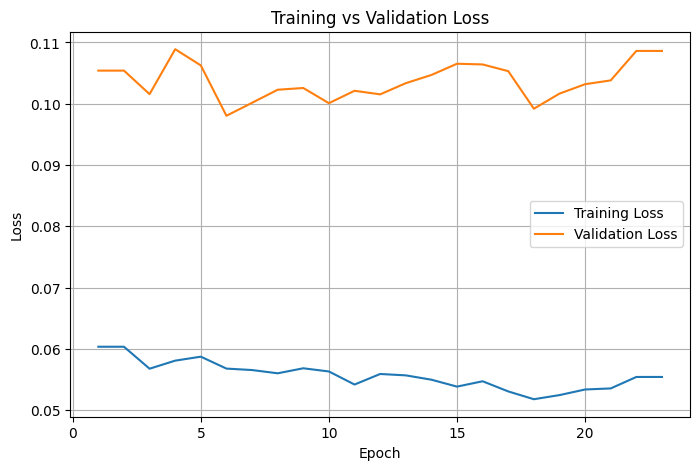

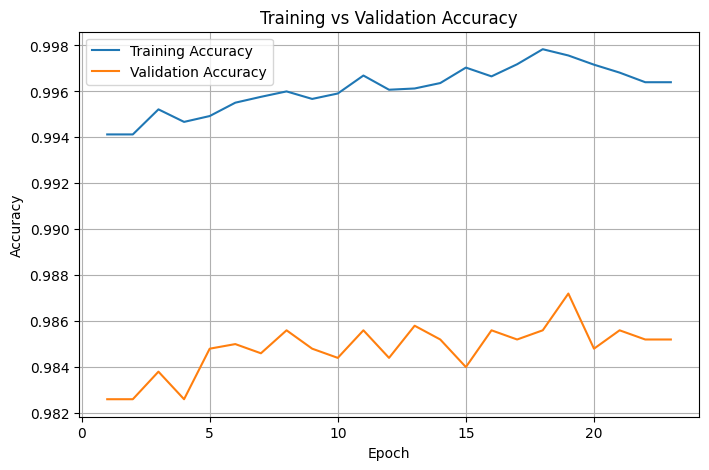


Final Test Results
------------------
Test Loss:     0.1055
Test Accuracy: 0.9834
Test Accuracy: 98.34%


In [33]:
# ============================================================
# TRAINING CURVES
# ============================================================

epochs_range = range(1, len(history["train_loss"]) + 1)


# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# Accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_acc"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# FINAL TEST EVALUATION
# ============================================================

test_pred, _ = forward_propagation_full(
    X_test,
    training=False
)

test_loss = total_loss(
    Y_test,
    test_pred,
    W1, W2, W3,
    l2_lambda=l2_lambda,
    l1_lambda=l1_lambda
)

test_acc = accuracy(
    Y_test,
    test_pred
)

print("\nFinal Test Results")
print("------------------")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

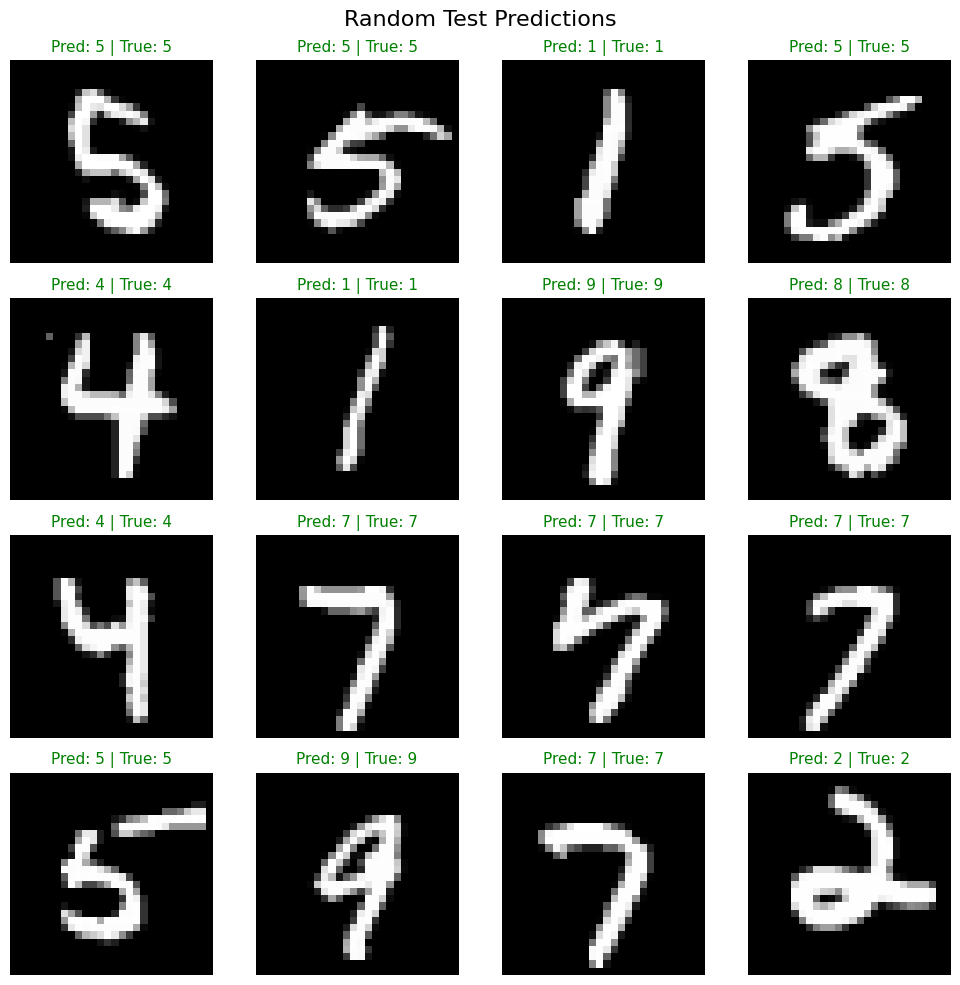

In [34]:
# ============================================================
# VISUALIZE RANDOM TEST PREDICTIONS
# ============================================================

# Generate predictions for the entire test set
test_pred, _ = forward_propagation_full(
    X_test,
    training=False
)

# Convert one-hot labels and probabilities to class labels
true_labels = np.argmax(Y_test, axis=1)
predicted_labels = np.argmax(test_pred, axis=1)

# Pick 16 random test examples
random_indices = np.random.choice(
    X_test.shape[0],
    size=16,
    replace=False
)

# Create 4 × 4 grid
fig, axes = plt.subplots(
    4, 4,
    figsize=(10, 10)
)

for ax, idx in zip(axes.ravel(), random_indices):

    # Reshape flattened 784 pixels back to 28 × 28
    image = X_test[idx].reshape(28, 28)

    true_label = true_labels[idx]
    predicted_label = predicted_labels[idx]

    # Check whether prediction is correct
    correct = predicted_label == true_label

    # Display image
    ax.imshow(image, cmap="gray")

    # Green for correct, red for incorrect
    if correct:
        title_color = "green"
    else:
        title_color = "red"

    ax.set_title(
        f"Pred: {predicted_label} | True: {true_label}",
        color=title_color,
        fontsize=11
    )

    ax.axis("off")

plt.suptitle(
    "Random Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()